# Insurance Charge Prediction

This notebook follows the assignment workflow with `insurance.csv`:
- Missing value strategies: drop and fill
- Outlier removal using IQR
- Categorical encoding using `get_dummies`
- Min-max feature scaling
- Model comparison: Linear, Polynomial (2-5), and tuned Random Forest


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pandas.api.types import is_numeric_dtype
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import PolynomialFeatures

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')


In [15]:
csv_path = Path('insurance.csv').resolve()
df = pd.read_csv(csv_path)
print(f'Loaded dataset from: {csv_path}')
print(f'Shape: {df.shape}')
display(df.head())
print('Missing values by column:')
display(df.isna().sum())


Loaded dataset from: /workspaces/insurance_predictiokn/insurance/insurance.csv
Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Missing values by column:


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

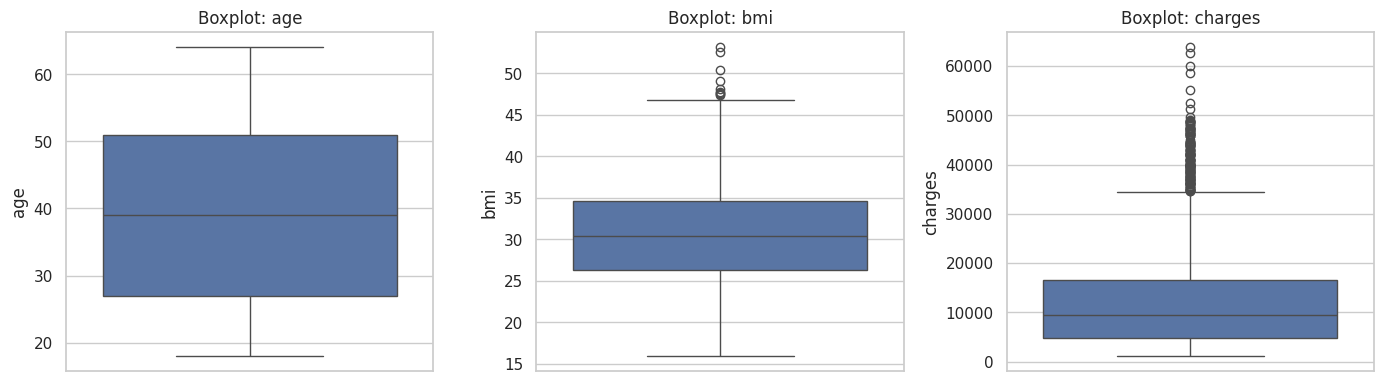

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['age', 'bmi', 'charges']):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(f'Boxplot: {col}')
plt.tight_layout()
plt.show()


In [17]:
def remove_outliers_iqr(data: pd.DataFrame, numeric_cols, factor: float = 1.5) -> pd.DataFrame:
    clean = data.copy()
    mask = pd.Series(True, index=clean.index)
    for col in numeric_cols:
        q1 = clean[col].quantile(0.25)
        q3 = clean[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - factor * iqr
        upper = q3 + factor * iqr
        mask &= clean[col].between(lower, upper)
    return clean.loc[mask].reset_index(drop=True)


def minmax_scale_train_test(x_train: pd.DataFrame, x_test: pd.DataFrame):
    train_min = x_train.min()
    train_max = x_train.max()
    denom = (train_max - train_min).replace(0, 1)
    x_train_scaled = (x_train - train_min) / denom
    x_test_scaled = (x_test - train_min) / denom
    return x_train_scaled, x_test_scaled


def preprocess(data: pd.DataFrame, missing_strategy: str):
    xdf = data.copy()

    if missing_strategy == 'drop':
        xdf = xdf.dropna().reset_index(drop=True)
    elif missing_strategy == 'fill':
        for col in xdf.columns:
            if is_numeric_dtype(xdf[col]):
                xdf[col] = xdf[col].fillna(xdf[col].mean())
            else:
                mode = xdf[col].mode(dropna=True)
                fill_value = mode.iloc[0] if not mode.empty else 'unknown'
                xdf[col] = xdf[col].fillna(fill_value)
    else:
        raise ValueError("missing_strategy must be either 'drop' or 'fill'")

    xdf = remove_outliers_iqr(xdf, ['age', 'bmi', 'children', 'charges'])
    xdf = pd.get_dummies(xdf, columns=['sex', 'smoker', 'region'], drop_first=True)

    x = xdf.drop(columns=['charges']).astype(float)
    y = xdf['charges']
    return x, y


def evaluate_model(name, model, x_train, x_test, y_train, y_test):
    model.fit(x_train, y_train)
    pred_train = model.predict(x_train)
    pred_test = model.predict(x_test)

    mse_train = mean_squared_error(y_train, pred_train)
    mse_test = mean_squared_error(y_test, pred_test)

    return {
        'Model': name,
        'Train_MSE': mse_train,
        'Test_MSE': mse_test,
        'Train_RMSE': np.sqrt(mse_train),
        'Test_RMSE': np.sqrt(mse_test),
    }


In [18]:
all_results = {}
best_rf_params = {}

for strategy in ['drop', 'fill']:
    x, y = preprocess(df, strategy)

    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=0.2, random_state=42
    )

    x_train_s, x_test_s = minmax_scale_train_test(x_train, x_test)

    rows = []
    rows.append(
        evaluate_model(
            'LinearRegression',
            LinearRegression(),
            x_train_s, x_test_s, y_train, y_test
        )
    )

    for degree in range(2, 6):
        poly = PolynomialFeatures(degree=degree, include_bias=False)
        x_train_p = poly.fit_transform(x_train_s)
        x_test_p = poly.transform(x_test_s)
        rows.append(
            evaluate_model(
                f'PolynomialRegression(degree={degree})',
                LinearRegression(),
                x_train_p, x_test_p, y_train, y_test
            )
        )

    rf = RandomForestRegressor(random_state=42)
    param_grid = {
        'max_depth': [None, 5, 10, 20],
        'max_features': ['sqrt', 'log2', 0.8],
        'criterion': ['squared_error', 'absolute_error', 'friedman_mse'],
        'n_estimators': [200],
    }

    grid = GridSearchCV(
        estimator=rf,
        param_grid=param_grid,
        cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
    )
    grid.fit(x_train_s, y_train)

    rf_result = evaluate_model(
        'RandomForestRegressor(tuned)',
        grid.best_estimator_,
        x_train_s, x_test_s, y_train, y_test
    )
    rf_result['Best_Params'] = str(grid.best_params_)
    rows.append(rf_result)

    result_df = pd.DataFrame(rows).sort_values('Test_MSE').reset_index(drop=True)
    all_results[strategy] = result_df
    best_rf_params[strategy] = grid.best_params_

    print(f'\n=== Missing-data strategy: {strategy} ===')
    display(result_df)



=== Missing-data strategy: drop ===


,Model,Train_MSE,Test_MSE,Train_RMSE,Test_RMSE,Best_Params
0,RandomForestRegressor(tuned),1.580571e+07,1.681205e+07,3975.639252,4100.250198,"{'criterion': 'squared_error', 'max_depth': 5,..."
1,PolynomialRegression(degree=2),1.879385e+07,1.793650e+07,4335.187248,4235.150166,NaN
2,LinearRegression,2.139530e+07,1.921998e+07,4625.505168,4384.059307,NaN
3,PolynomialRegression(degree=3),1.694662e+07,2.005048e+07,4116.627295,4477.775688,NaN
4,PolynomialRegression(degree=4),1.468186e+07,5.720487e+07,3831.690952,7563.390184,NaN
5,PolynomialRegression(degree=5),1.215031e+07,1.563300e+10,3485.729673,125032.014312,NaN



=== Missing-data strategy: fill ===


,Model,Train_MSE,Test_MSE,Train_RMSE,Test_RMSE,Best_Params
0,RandomForestRegressor(tuned),1.580571e+07,1.681205e+07,3975.639252,4100.250198,"{'criterion': 'squared_error', 'max_depth': 5,..."
1,PolynomialRegression(degree=2),1.879385e+07,1.793650e+07,4335.187248,4235.150166,NaN
2,LinearRegression,2.139530e+07,1.921998e+07,4625.505168,4384.059307,NaN
3,PolynomialRegression(degree=3),1.694662e+07,2.005048e+07,4116.627295,4477.775688,NaN
4,PolynomialRegression(degree=4),1.468186e+07,5.720487e+07,3831.690952,7563.390184,NaN
5,PolynomialRegression(degree=5),1.215031e+07,1.563300e+10,3485.729673,125032.014312,NaN


In [19]:
print('Best Random Forest hyperparameters by strategy:')
for strategy, params in best_rf_params.items():
    print(f'{strategy}: {params}')


Best Random Forest hyperparameters by strategy:
drop: {'criterion': 'squared_error', 'max_depth': 5, 'max_features': 0.8, 'n_estimators': 200}
fill: {'criterion': 'squared_error', 'max_depth': 5, 'max_features': 0.8, 'n_estimators': 200}
